<a href="https://colab.research.google.com/github/joliebarga/CS131_release/blob/master/option_a_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: Setosa.io: Image Kernels Explained Visually (https://setosa.io/ev/image-kernels/) I found this site while trying to understand why my sharpen kernel was producing weird outputs. It’s an interactive demo where you can drag your mouse over an image and see exactly how the kernel affects each pixel in real time. This really helped me understand what the kernel values are doing and the difference between weak and strong sharpen filters.
* Source 2: Scikit-image - Unsharp Masking documentation (https://scikit-image.org/docs/stable/auto_examples/filters/plot_unsharp_mask.html) — This is the official scikit-image documentation for unsharp masking which explains how subtracting a blurred version from the original enhances edges. It shows examples with different radius and amount parameters which helped me understand how changing sigma affects how much detail gets enhanced vs how much noise gets introduced.
* Source 3: Scipy gaussian_filter documentation (https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html) I used this to figure out how to implement gaussian_filter in my unsharp mask code. The documentation explains how the sigma parameter controls the strength of the blur, which I tested directly by comparing sigma = 1 and sigma = 2 in my implementation.
* Source 4: YouTube - Computerphile "How Blurs & Filters Work" (https://www.youtube.com/watch?v=C_zFhWdM4ic) This video gives a really clear visual explanation of how convolution filters work on images. It covers blur and sharpen filters and explains intuitively why certain kernel values produce certain effects which helped me understand what I was implementing.
* Source 5: LearnOpenCV - Edge Detection Using OpenCV (https://learnopencv.com/edge-detection-using-opencv/) TThis tutorial explains how Sobel edge detection works by using separate kernels for horizontal and vertical gradients. It also shows how these are combined into a gradient magnitude, which I used in my code. The tutorial also compares Sobel to other methods like Canny, which helped me understand the strengths and limitations of the approach I used.

## Code (70 points)



In [25]:
from filters import conv_fast
from scipy.ndimage import convolve
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize

# load my images
img1 = io.imread('IMG_3518.JPG')
img2 = io.imread('IMG_3677.jpg')
img3 = io.imread('IMG_5893.jpg')
img4 = io.imread('IMG_5894.jpg')

def shrink(img):
    return resize(img, (100, 100))

imgs = [shrink(img1), shrink(img2), shrink(img3), shrink(img4)]
names = ['Picnic', 'Beach', 'Cliffs', 'Polo Club']

## Filter Exploration

For this exploration, I tested three different image filters on four of my own photos: a sharpening filter, Sobel edge detection, and an unsharp mask. I chose these because they each handle image structure in a slightly different way using convolution. Sharpening makes existing edges stand out more, Sobel focuses on detecting where edges are, and unsharp masking is a more controlled version of sharpening that first blurs the image and then subtracts it to enhance detail.

I also picked four photos that are pretty different from each other so I could see how the filters behave in different situations: a colorful picnic spread with a really busy checkered blanket, a beach with soft palm leaves, Hawaiian cliffs with strong geometric edges, and the Honolulu Polo Club with horses and a fence against a mountain backdrop. For each filter, I tried two intensity levels to see how the strength of the effect changes depending on the image. Going in, I expected that images with cleaner, more defined edges like the Cliffs and Polo Club would respond better than something like the Picnic, which has a lot of texture and small details everywhere, and testing across all four helped confirm that.

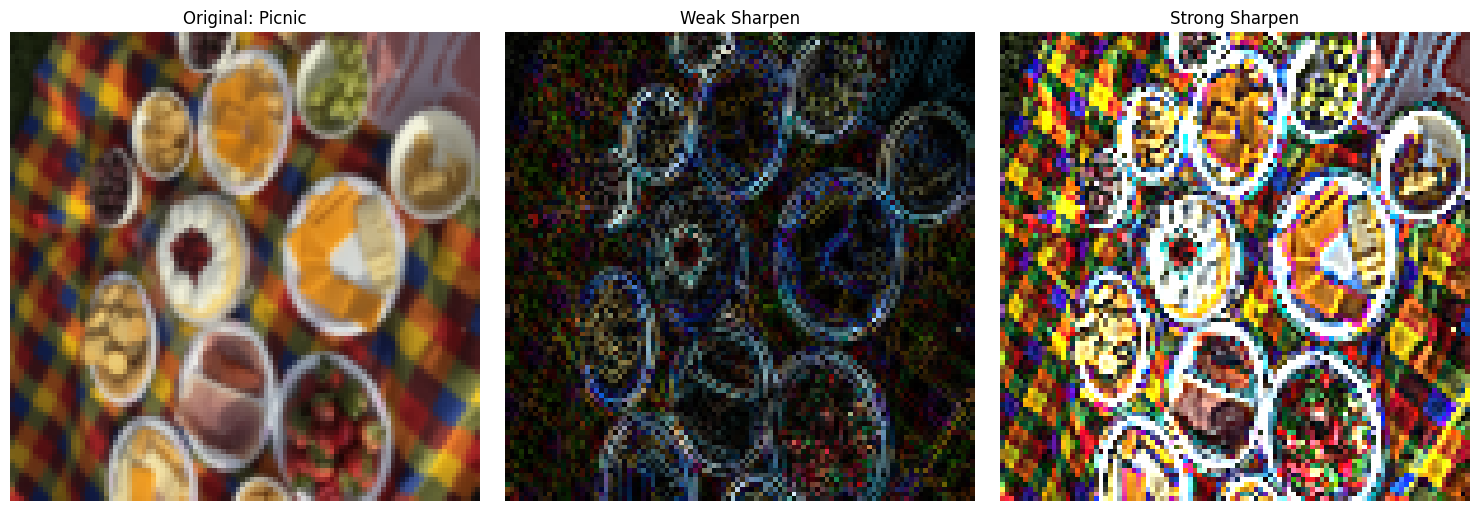

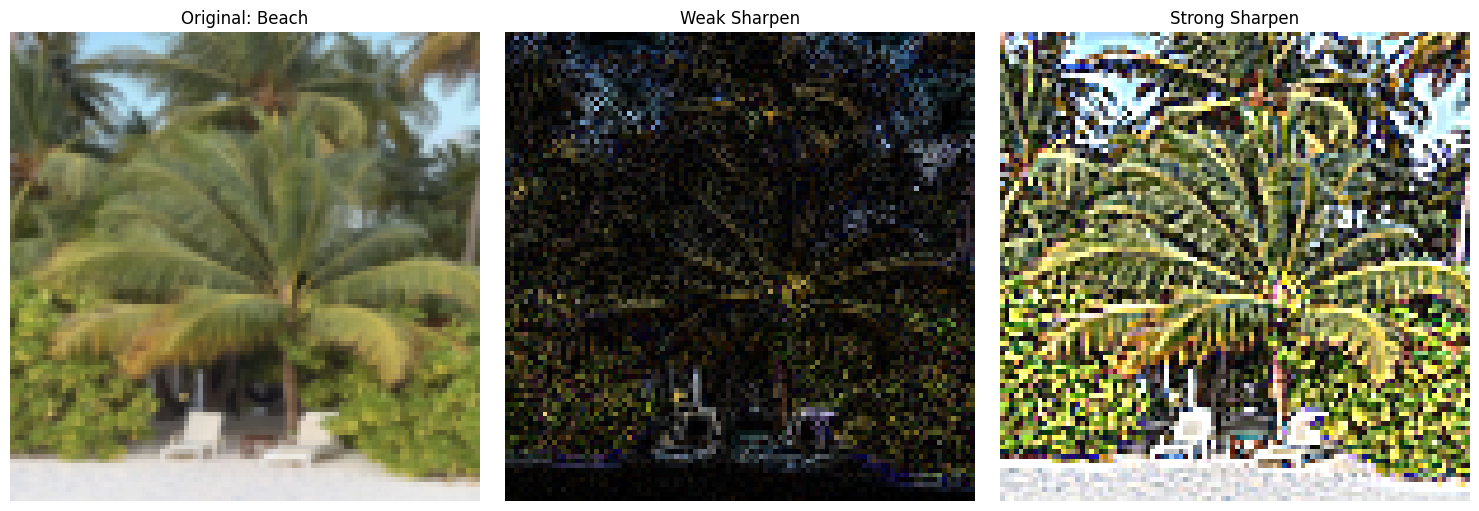

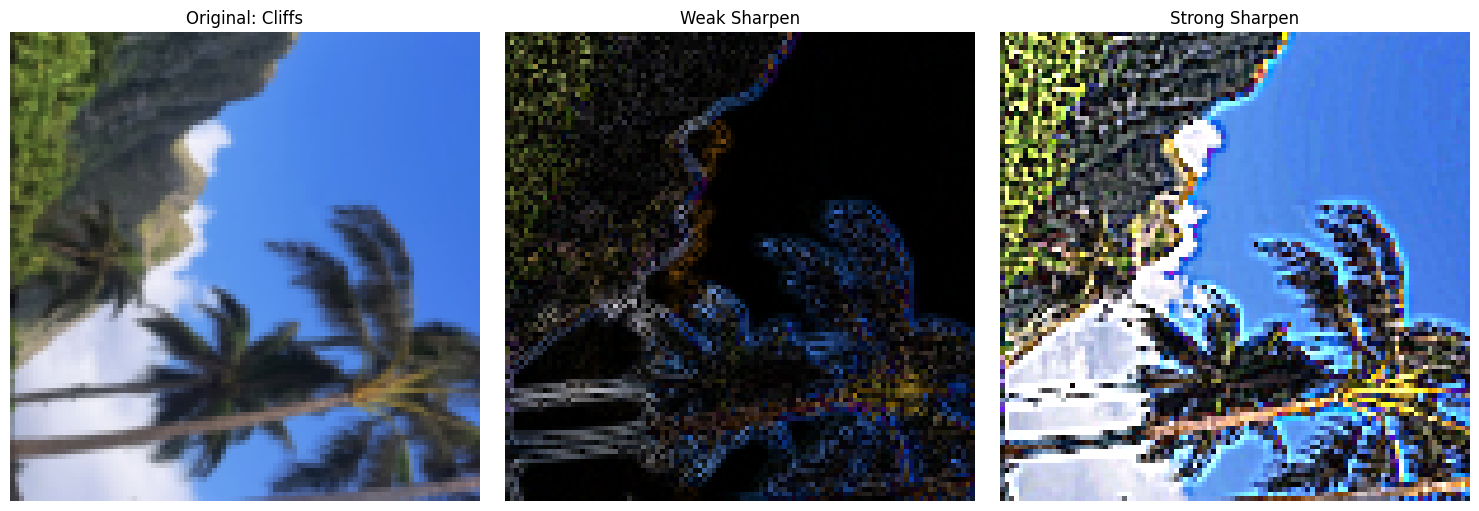

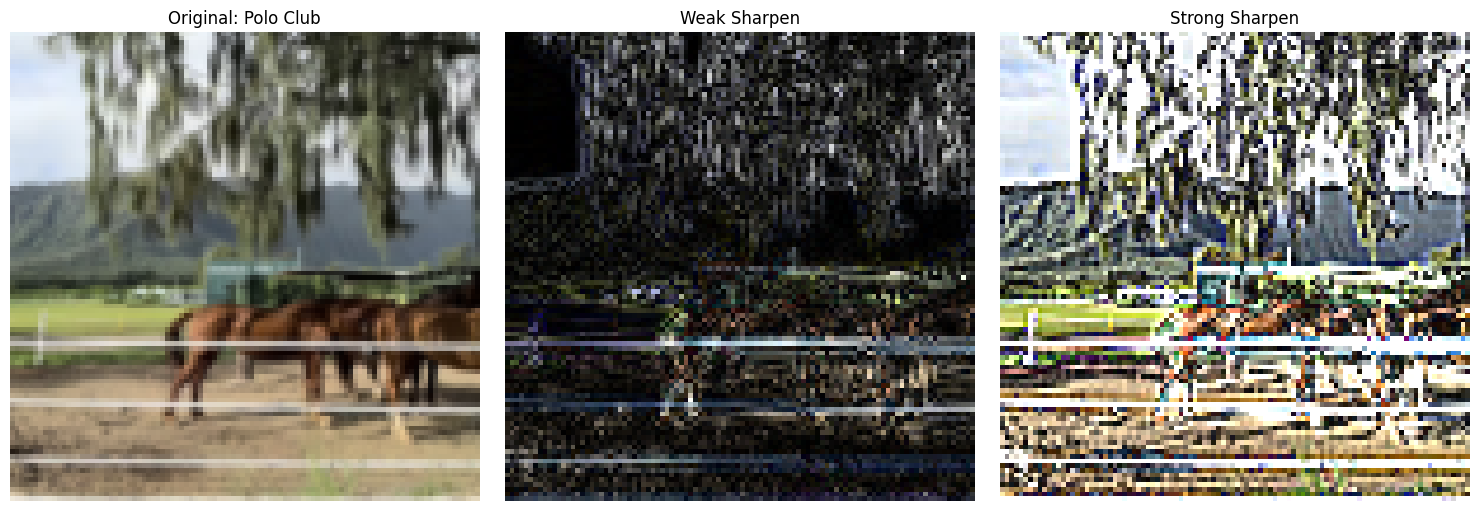

In [26]:
sharpen_weak = np.array([[0, -1, 0],
                         [-1, 4, -1],
                         [0, -1, 0]])

sharpen_strong = np.array([[-1, -1, -1],
                           [-1,  9, -1],
                           [-1, -1, -1]])

# apply to each image
for img, name in zip(imgs, names):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original: ' + name)
    axes[0].axis('off')

    # have to do each color channel separately
    weak = np.zeros_like(img)
    strong = np.zeros_like(img)
    for c in range(3):
        weak[:,:,c] = np.clip(np.abs(convolve(img[:,:,c], sharpen_weak)), 0, 1)
        strong[:,:,c] = np.clip(np.abs(convolve(img[:,:,c], sharpen_strong)), 0, 1)

    axes[1].imshow(weak)
    axes[1].set_title('Weak Sharpen')
    axes[1].axis('off')

    axes[2].imshow(strong)
    axes[2].set_title('Strong Sharpen')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## Sharpen Results

The weak sharpen made the images look slightly crisper without being too
obvious and the strong sharpen was way more intense because it made edges really pop
but also introduced a lot of noise especially on the Picnic image which had
a really busy checkered blanket pattern. The Beach and Cliffs photos responded
better to sharpening since they had cleaner edges from the palm trees and
rocks. The Polo Club horses actually looked really good with strong sharpen
since the horse fur had a lot of fine detail that got enhanced.

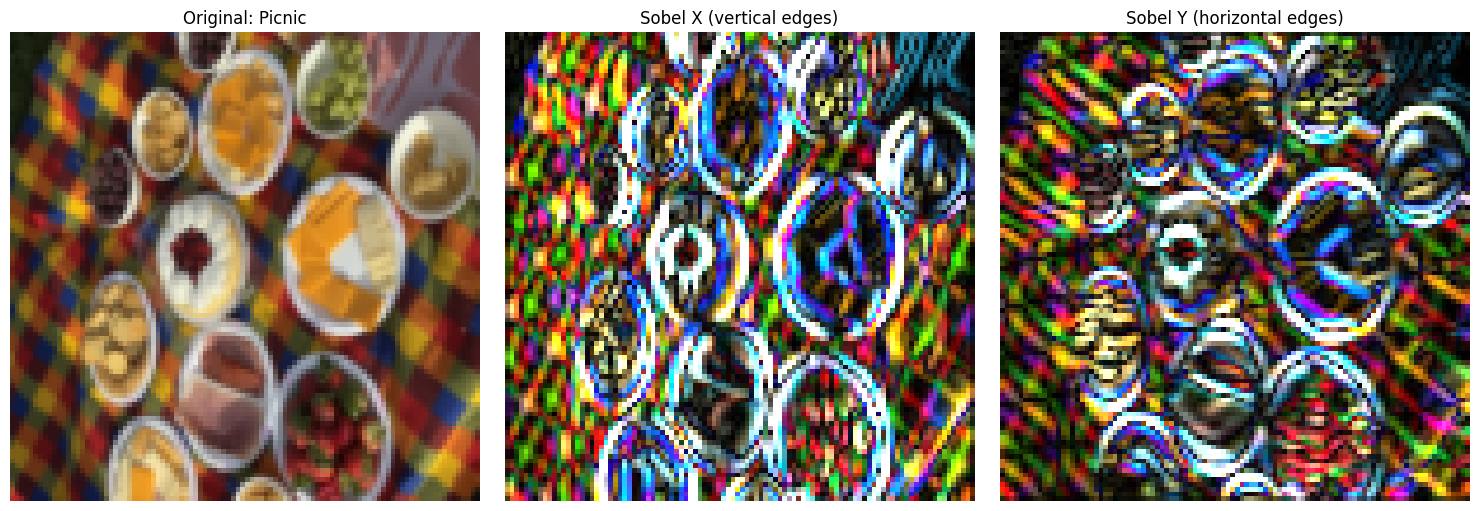

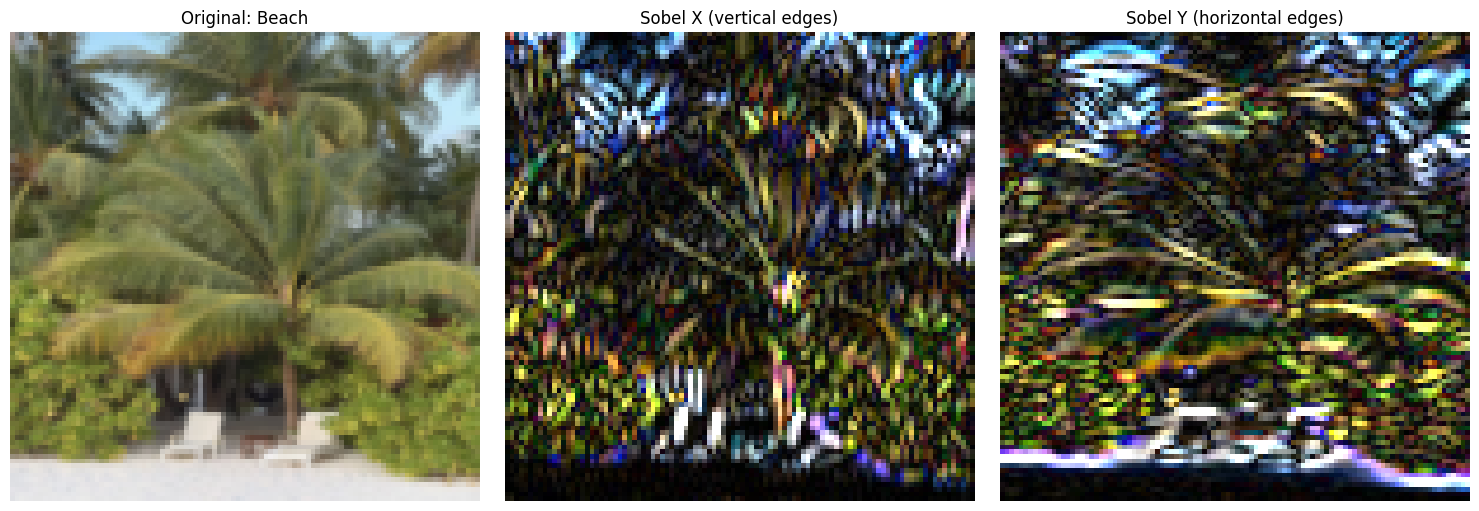

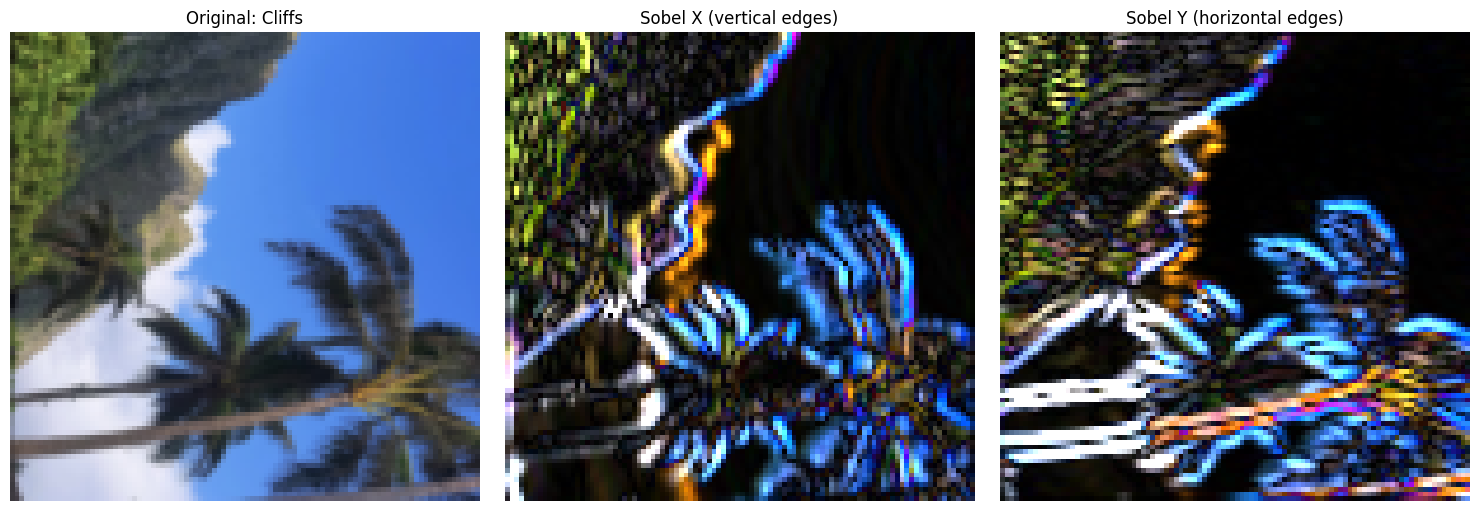

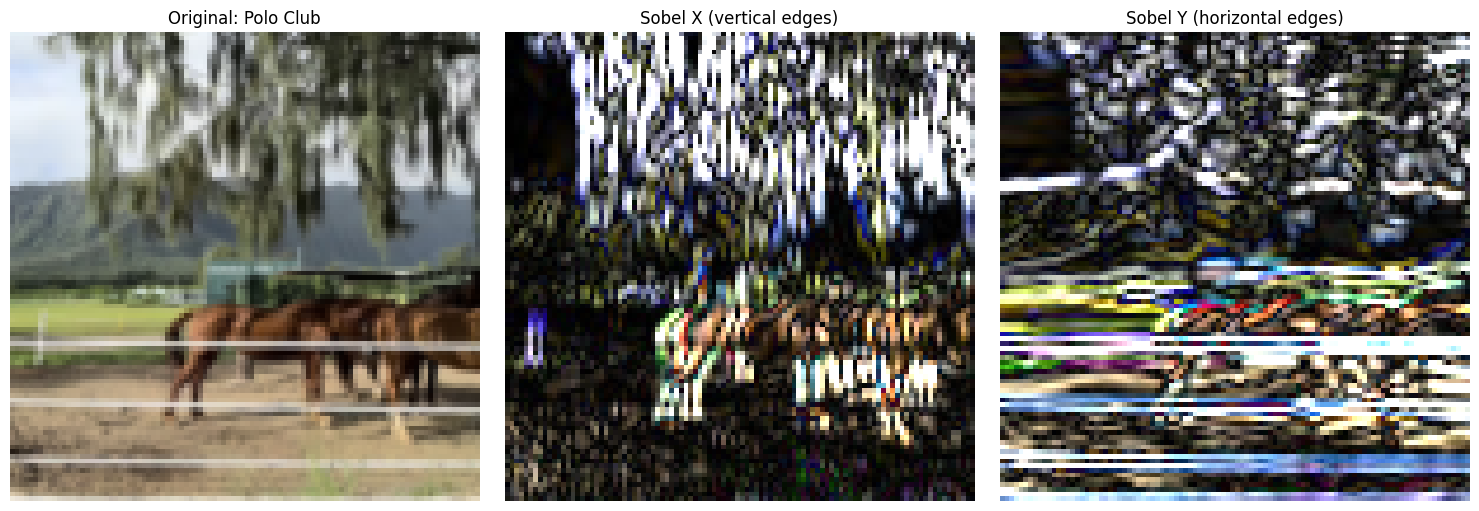

In [27]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# apply to each image
for img, name in zip(imgs, names):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original: ' + name)
    axes[0].axis('off')

    # have to do each color channel separately
    sx = np.zeros_like(img)
    sy = np.zeros_like(img)
    for c in range(3):
        sx[:,:,c] = np.clip(np.abs(convolve(img[:,:,c], sobel_x)), 0, 1)
        sy[:,:,c] = np.clip(np.abs(convolve(img[:,:,c], sobel_y)), 0, 1)

    axes[1].imshow(sx)
    axes[1].set_title('Sobel X (vertical edges)')
    axes[1].axis('off')

    axes[2].imshow(sy)
    axes[2].set_title('Sobel Y (horizontal edges)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## Sobel Results
This one was really interesting because Sobel X picked up vertical edges and Sobel Y picked up horizontal ones, which you can see really clearly in the Cliffs image. Sobel X highlights the vertical cliff face, while Sobel Y picks up the horizon line between the sky and the cliff. The Picnic image was the hardest since the checkered blanket has edges going in every direction, so both filters ended up picking up everything. The Beach image was kind of underwhelming with Sobel since the palm leaves are softer and don’t have really sharp edges. This made me realize that edge detection doesn’t work as well when an image has too many small repeated patterns, because the filter responds to all of them instead of just the main edges.

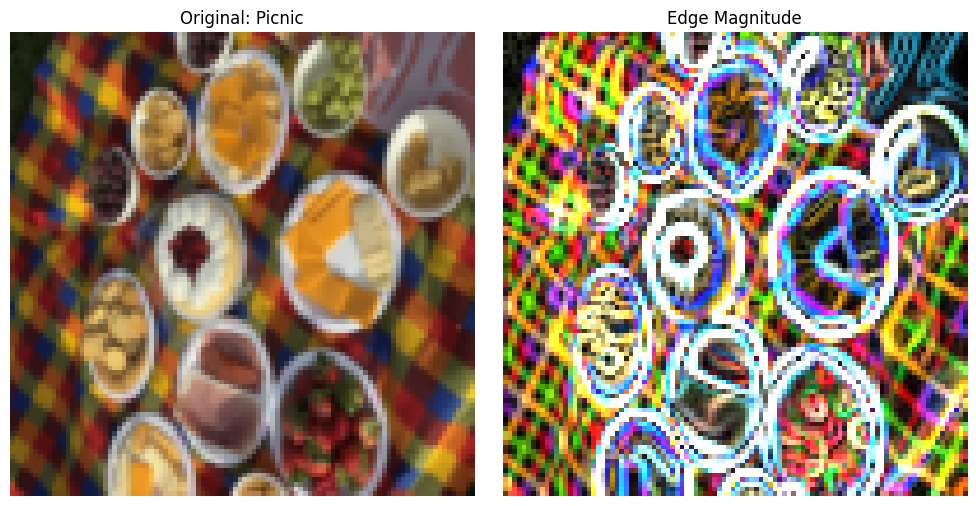

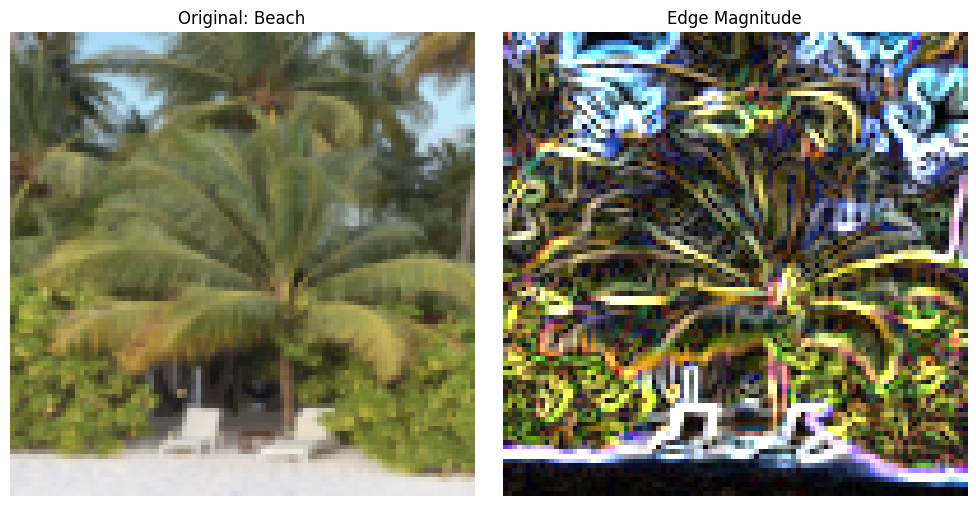

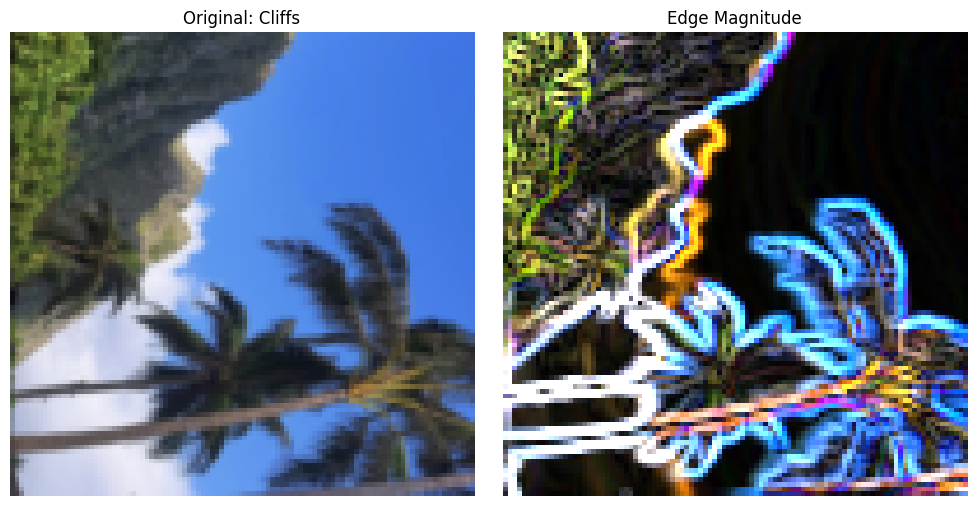

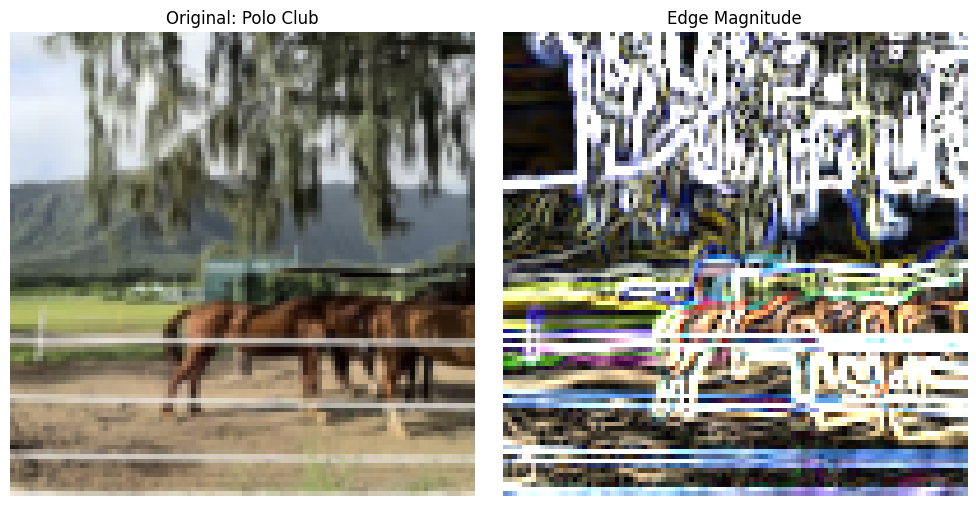

In [28]:
# combine sobel x and y to get full edge magnitude
for img, name in zip(imgs, names):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original: ' + name)
    axes[0].axis('off')

    sx = np.zeros_like(img)
    sy = np.zeros_like(img)
    for c in range(3):
        sx[:,:,c] = convolve(img[:,:,c], sobel_x)
        sy[:,:,c] = convolve(img[:,:,c], sobel_y)

    mag = np.clip(np.sqrt(sx**2 + sy**2), 0, 1)
    axes[1].imshow(mag)
    axes[1].set_title('Edge Magnitude')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## Edge Magnitude Results
Combining Sobel X and Y using the gradient magnitude formula sqrt(Gx² + Gy²) made it way easier to see where the edges actually are in each image. The Cliffs and Polo Club images looked the best since they have really clear edges as you can see the cliff outline and fence posts pretty easily but, the Picnic image was still pretty noisy, but you could still make out the plate edges better than before. Overall, the edge magnitude was more useful than just Sobel X or Y alone since it captures edges in all directions instead of just one.

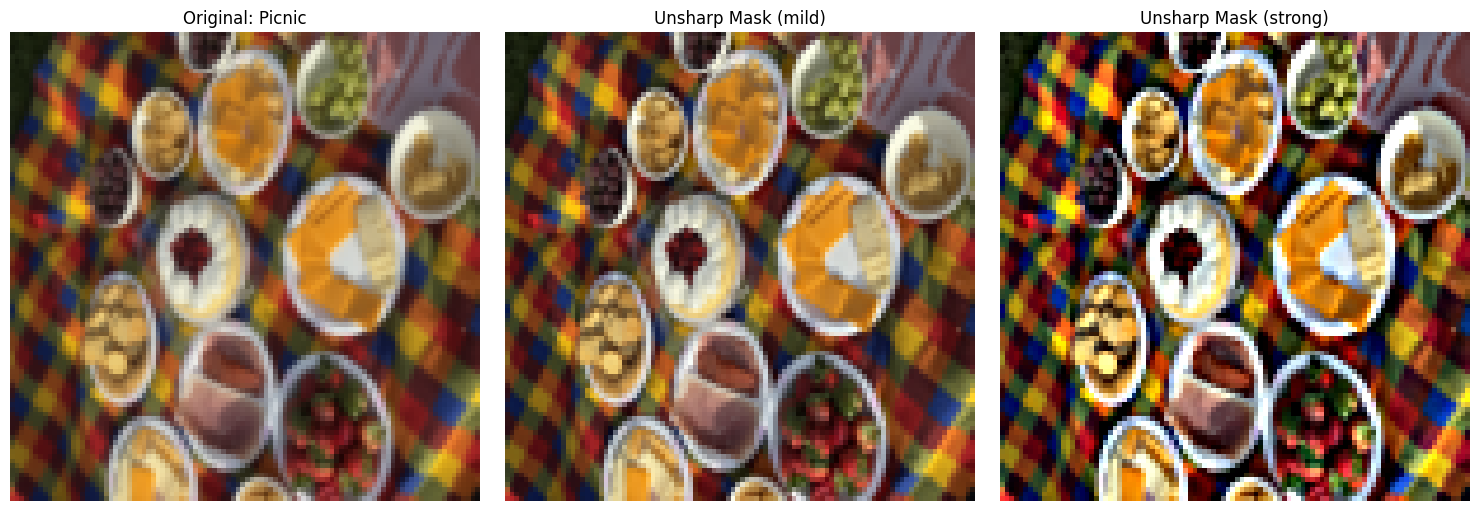

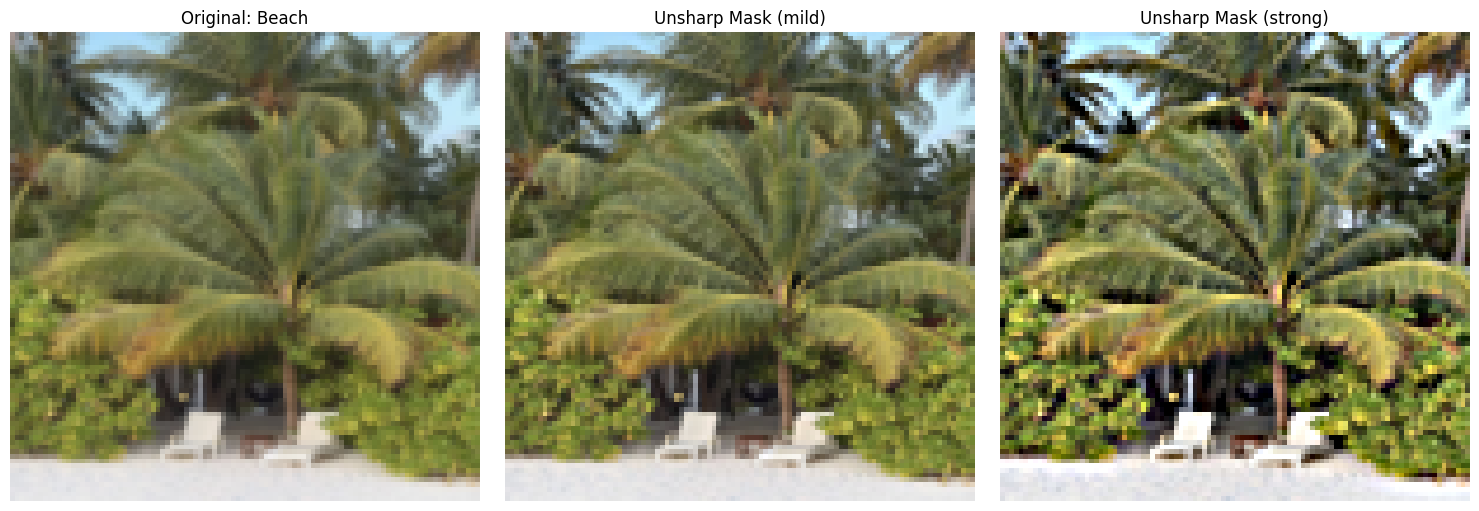

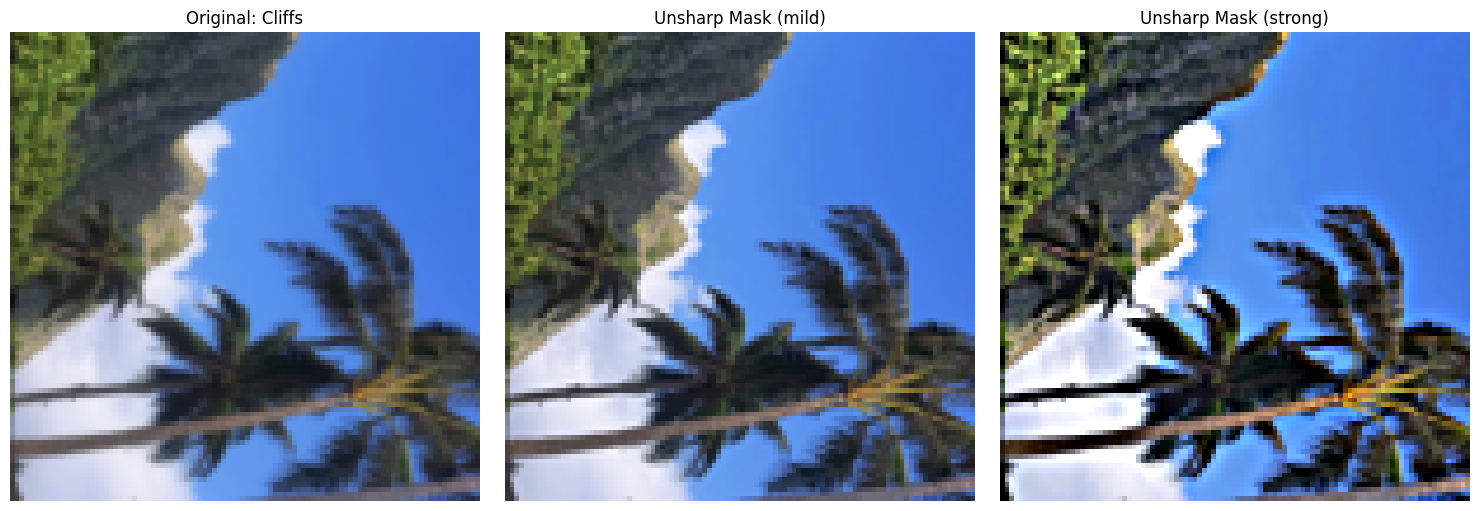

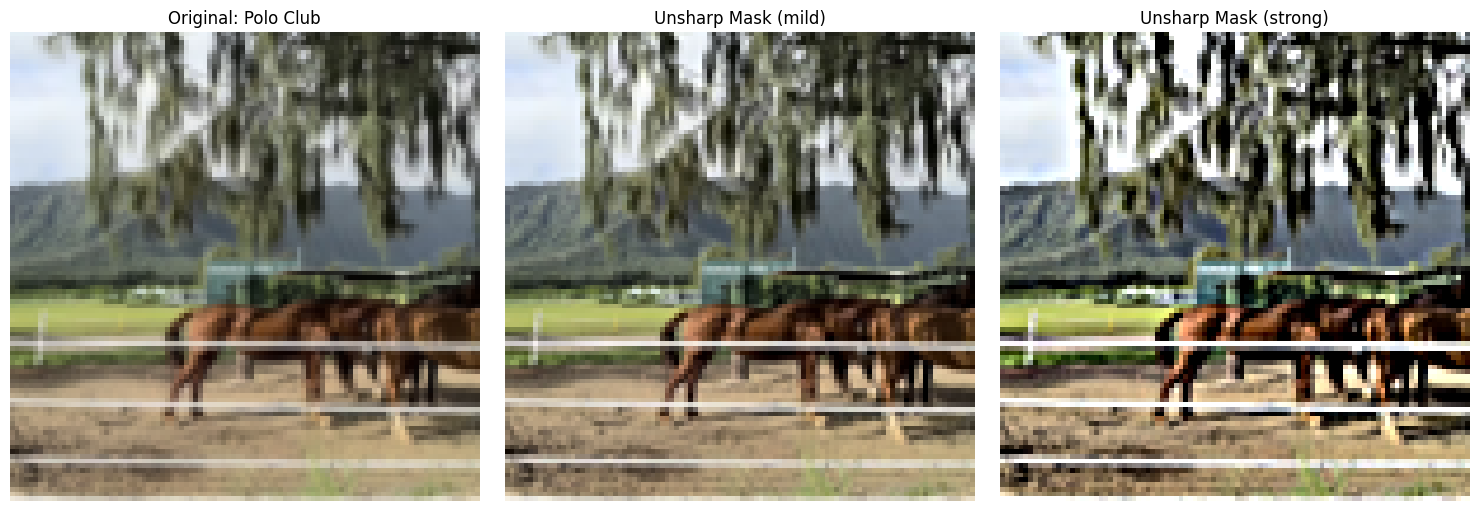

In [29]:
# unsharp mask - basically you blur the image and subtract it from the original
# this makes edges pop more than a regular sharpen kernel
from scipy.ndimage import gaussian_filter

for img, name in zip(imgs, names):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original: ' + name)
    axes[0].axis('off')

    mild = np.zeros_like(img)
    strong = np.zeros_like(img)
    for c in range(3):
        b1 = gaussian_filter(img[:,:,c], sigma=1)
        b2 = gaussian_filter(img[:,:,c], sigma=2)
        mild[:,:,c] = np.clip(img[:,:,c] + 0.5*(img[:,:,c] - b1), 0, 1)
        strong[:,:,c] = np.clip(img[:,:,c] + 1.5*(img[:,:,c] - b2), 0, 1)

    axes[1].imshow(mild)
    axes[1].set_title('Unsharp Mask (mild)')
    axes[1].axis('off')

    axes[2].imshow(strong)
    axes[2].set_title('Unsharp Mask (strong)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## Unsharp Mask Results
The unsharp mask worked really differently from the basic sharpen kernel and instead
of just using a fixed kernel, it blurs the image first using a Gaussian filter
(which is actually the same separable Gaussian from Part 3 of the main notebook)
and then subtracts that blur from the original to enhance edges. The mild version
looked really natural on all 4 images especially the Polo Club photo where the
horse fur detail came out really nicely. The strong version was too aggressive on
the Picnic image since there was already so much going on, but worked great on the
Beach image which had softer edges that needed more enhancement. Compared to the
basic sharpen kernel, unsharp mask produced cleaner results with less noise because
the Gaussian blur step smooths out small variations before the subtraction.

### Direct Comparison of Filters

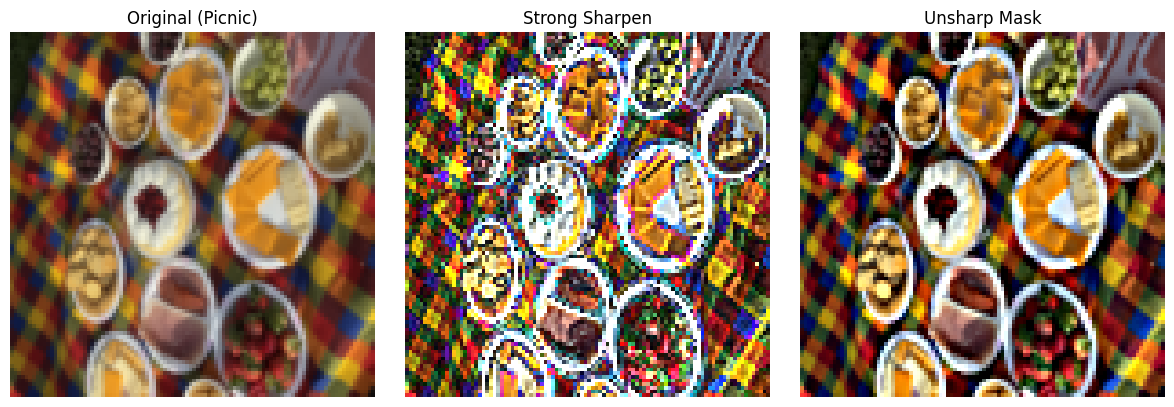

In [30]:
# picnic
img = imgs[0]

# strong sharpen for picnic
strong = np.zeros_like(img)
for c in range(3):
    strong[:,:,c] = np.clip(np.abs(convolve(img[:,:,c], sharpen_strong)), 0, 1)

# unsharp mask for picnic
unsharp = np.zeros_like(img)
for c in range(3):
    b = gaussian_filter(img[:,:,c], sigma=2)
    unsharp[:,:,c] = np.clip(img[:,:,c] + 1.5*(img[:,:,c] - b), 0, 1)

# all 3 side by side picnic pic w filter
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original (Picnic)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(strong)
plt.title('Strong Sharpen')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(unsharp)
plt.title('Unsharp Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

To better understand the differences between these filters, I compared the strong sharpen filter directly with the unsharp mask on the same image. Even though both are meant to enhance edges, they end up behaving pretty differently. The sharpen filter uses a fixed kernel that boosts contrast around edges, but it also ends up amplifying noise, especially in more detailed areas like the checkered blanket in the Picnic photo. The unsharp mask, on the other hand, smooths the image first using a Gaussian filter and then enhances edges, which makes the result look a lot cleaner and more controlled. From this, it felt like unsharp masking works better on more complex images, while basic sharpening is better suited for simpler scenes with less texture.

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

## Writeup

For this exploration, I implemented three different image filters on four of my own photos: a sharpen filter, Sobel edge detection, and an unsharp mask. All three build directly on the convolution concepts from the main notebook, but I used them to analyze how different filters behave across images with different levels of detail and texture.

The sharpen filter uses a kernel that emphasizes the center pixel relative to its neighbors, which increases contrast around edges and makes details appear more defined. I tested two versions, a weak and strong filter, and found that the strong version often amplified noise, especially in more complex images like the Picnic photo with its checkered blanket. In contrast, it worked much better on cleaner images like the Polo Club horses, where the structure is more defined and there is less background noise.

The Sobel filter detects edges by computing gradients in the x and y directions separately, which connects directly to the partial derivative concept from the homework. Combining both directions using the gradient magnitude formula sqrt(Gx² + Gy²) produced the most complete edge representation. However, on more detailed images, the filter responded to too many small intensity changes, making the output noisier and less focused on the main structure.

The unsharp mask was the most interesting filter because it works differently from a standard sharpening kernel. Instead of directly enhancing the center pixel, it subtracts a Gaussian-blurred version of the image from the original to isolate and amplify edges. This connects to the separable Gaussian filter from Part 3 of the main notebook. Compared to basic sharpening, it produced cleaner results with less noise because the Gaussian smoothing step removes small variations before the subtraction, which made the result look cleaner overall.

Testing across four different images showed that filters perform very differently
depending on the image content and photos with strong defined edges responded much
better to all three filters than photos with soft textures. And, overall, the main takeaway was that the “best” filter depends on the image because strong sharpening works well on clean detailed subjects, while busy images need smoother methods like unsharp masking to avoid amplifying noise.